# Shannon entropy at entrenched vs non-entrenched sites

Classify sites into three categories per V family:
1. **Within-family entrenched** - sites showing entrenchment between V genes within the same family
2. **Between-family only** - sites entrenched between V families but NOT within-family entrenched
3. **No entrenchment** - variable sites with no detected entrenchment

Then compare the germline amino acid Shannon entropy across these categories.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import (
    load_entrenched_sites,
    calculate_shannon_entropy_per_site,
    GERMLINE_PATH_DICTIONARY,
)

numbering_scheme = 'chothia'
germline_codons_df = pd.read_csv(GERMLINE_PATH_DICTIONARY[numbering_scheme], dtype={'site': str})

In [2]:
_, _, _, _, within_dfs, _ = load_entrenched_sites(numbering_scheme=numbering_scheme)


def get_site_categories(v_family, within_dfs, between_pair,
                        numbering_scheme='chothia',
                        base_dir='_output/entrenchment_analysis'):
    """Return (within_sites, between_only_sites) for a given V family.

    Parameters
    ----------
    v_family : str
        e.g. 'IGHV1'
    within_dfs : DataFrame
        All within-family entrenched rows.
    between_pair : tuple of str
        The specific pairwise comparison (e.g. ('IGHV1', 'IGHV3')).
        v_family must be one of the two.
    """
    within_sites = set(
        within_dfs.loc[within_dfs.v_family == v_family, 'site'].unique()
    ) if not within_dfs.empty else set()

    # Read the specific comparison file directly to avoid cross-contamination
    v1, v2 = sorted(between_pair)
    vs_file = f'{base_dir}/{numbering_scheme}/entrenched_aa_sites_{v1}_vs_{v2}.csv'
    vs_pair_df = pd.read_csv(vs_file, dtype={'site': str})
    between_sites = set(
        vs_pair_df.loc[vs_pair_df.v_family == v_family, 'site'].unique()
    )

    between_only_sites = between_sites - within_sites
    return within_sites, between_only_sites


# Sanity check
for vf in ['IGHV1', 'IGHV3']:
    w, b = get_site_categories(vf, within_dfs, between_pair=('IGHV1', 'IGHV3'))
    print(f'{vf}  within={sorted(w)}  between-only={sorted(b)}')

IGHV1  within=['33', '50', '52']  between-only=['16', '35', '73', '9', '94']
IGHV3  within=['33', '35', '50', '52', '53']  between-only=['16', '73', '9', '94']


In [3]:
between_pair = ('IGHV1', 'IGHV3')
v_families = list(between_pair)
entropy_records = []

for v_family in v_families:
    entropy_df = calculate_shannon_entropy_per_site(germline_codons_df, v_families=[v_family])
    within_sites, between_only_sites = get_site_categories(
        v_family, within_dfs, between_pair=between_pair
    )

    def classify(site):
        if site in within_sites:
            return 'Within-family entrenched'
        elif site in between_only_sites:
            return 'Between-family only'
        return 'No entrenchment'

    entropy_df['category'] = entropy_df['site'].map(classify)
    entropy_df['v_family'] = v_family
    entropy_records.append(entropy_df)

    print(f"\n{v_family}")
    print(entropy_df.groupby('category')['site'].apply(list).to_string())

combined_df = pd.concat(entropy_records, ignore_index=True)


IGHV1
category
Between-family only                                       [16, 35, 73, 9, 94]
No entrenchment             [1, 11, 14, 17, 2, 20, 24, 27, 29, 30, 31, 32,...
Within-family entrenched                                         [33, 50, 52]

IGHV3
category
Between-family only                                           [16, 73, 9, 94]
No entrenchment             [1, 10, 11, 12, 13, 15, 18, 19, 2, 20, 22, 23,...
Within-family entrenched                                 [33, 35, 50, 52, 53]


## Within-family entrenched vs not (2 categories, as in v_families_dasm.ipynb)

/tmp/ipykernel_1812120/1385690241.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vf_df, x='category_2', y='shannon_entropy',
/tmp/ipykernel_1812120/1385690241.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, fontsize=10)
/tmp/ipykernel_1812120/1385690241.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vf_df, x='category_2', y='shannon_entropy',
/tmp/ipykernel_1812120/1385690241.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabel

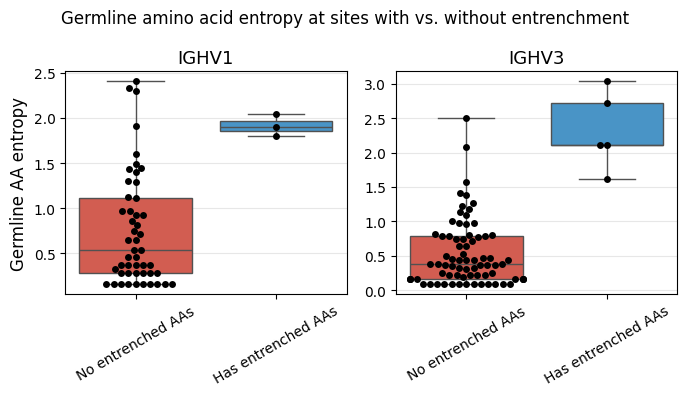

In [4]:
# 2-category plot: within-family entrenched vs not (matches v_families_dasm.ipynb)
combined_2cat = combined_df.copy()
combined_2cat['category_2'] = combined_2cat['category'].map(
    lambda c: 'Has entrenched AAs' if c == 'Within-family entrenched' else 'No entrenched AAs'
)

fig, axes = plt.subplots(1, len(v_families), figsize=(7, 4))
for v_family, ax in zip(v_families, axes):
    vf_df = combined_2cat[combined_2cat.v_family == v_family]
    sns.boxplot(data=vf_df, x='category_2', y='shannon_entropy',
                palette=['#e74c3c', '#3498db'], ax=ax, whis=[0, 100])
    sns.swarmplot(data=vf_df, x='category_2', y='shannon_entropy',
                  color='black', size=5, ax=ax)

    ax.set_xlabel('', fontsize=12)
    ax.set_ylabel('Germline AA entropy', fontsize=12)
    ax.set_title(v_family, fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
axes[1].set_ylabel('')
fig.suptitle('Germline amino acid entropy at sites with vs. without entrenchment')
plt.tight_layout()
fig.savefig('figures/shannon_entropy_entrenchment_comparison_within_family.png', dpi=600, bbox_inches='tight')
plt.show()

## 3 categories: within-family, between-family only, no entrenchment

/tmp/ipykernel_1812120/2704293472.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vf_df, x='category', y='shannon_entropy',
/tmp/ipykernel_1812120/2704293472.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=10)
/tmp/ipykernel_1812120/2704293472.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vf_df, x='category', y='shannon_entropy',
/tmp/ipykernel_1812120/2704293472.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels

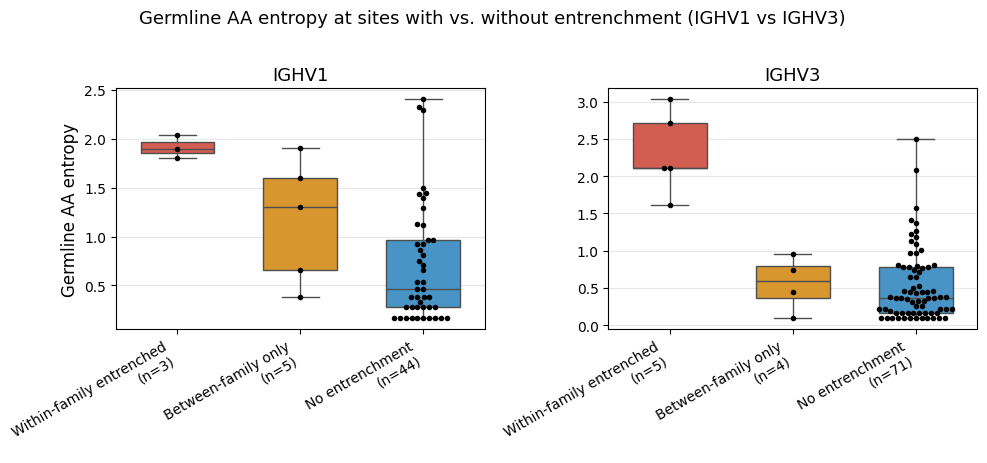

In [6]:
category_order = ['Within-family entrenched', 'Between-family only', 'No entrenchment']
palette = {'Within-family entrenched': '#e74c3c',
           'Between-family only': '#f39c12',
           'No entrenchment': '#3498db'}

fig, axes = plt.subplots(1, len(v_families), figsize=(5 * len(v_families), 4.5))

pair_label = f' ({" vs ".join(between_pair)})' if between_pair else ' (all comparisons)'

for v_family, ax in zip(v_families, axes):
    vf_df = combined_df[combined_df.v_family == v_family]
    sns.boxplot(data=vf_df, x='category', y='shannon_entropy',
                order=category_order, palette=palette,
                ax=ax, whis=[0, 100], width=0.6)
    sns.swarmplot(data=vf_df, x='category', y='shannon_entropy',
                  order=category_order, color='black', size=4, ax=ax)

    ax.set_title(v_family, fontsize=13)
    ax.set_ylabel('Germline AA entropy' if ax == axes[0] else '', fontsize=12)
    ax.set_xlabel('')

    # Build tick labels with counts
    tick_labels = []
    for cat in category_order:
        n = (vf_df['category'] == cat).sum()
        tick_labels.append(f'{cat}\n(n={n})')
    ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle(f'Germline AA entropy at sites with vs. without entrenchment{pair_label}',
             fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig('figures/shannon_entropy_3cat_entrenchment.png', dpi=300, bbox_inches='tight')
plt.show()